# Algoritmos de búsqueda en árboles

Este cuaderno reúne en un solo lugar las implementaciones desarrolladas durante el estudio de:

- búsqueda primero a lo ancho;
- búsqueda primero en profundidad;
- búsqueda primero el mejor;
- búsqueda A\*;
- búsqueda de costo uniforme;
- el problema de las jarras;
- el mapa de ciudades de Rumania.

La implementación está comentada con fines de estudio. Además, `getchildrens()` devuelve una lista dinámica que contiene **solamente hijos válidos**, sin rellenarla con `None`.

## Contenido

1. [Importaciones](#1-importaciones)
2. [Clase Node](#2-clase-node)
3. [Clase Tree y algoritmos](#3-clase-tree-y-algoritmos)
4. [Problema de las jarras](#4-problema-de-las-jarras)
5. [Mapa de ciudades de Rumania](#5-mapa-de-ciudades-de-rumania)
6. [Tic-Tac-Toe con Minimax](#6-tic-tac-toe-con-minimax)
7. [Comparación de los algoritmos](#7-comparación-de-los-algoritmos)

## 1. Importaciones

`queue.Queue` se usa en búsqueda a lo ancho y `queue.PriorityQueue` en las búsquedas que ordenan los nodos por heurística o costo. `pydot` permite dibujar el árbol construido.

In [5]:
%pip install numpy pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\EIA2024\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import queue

import numpy as np

import pydot
from IPython.display import Image, display

## 2. Clase Node

`Node` representa un estado dentro del árbol de búsqueda. Para resolver un problema concreto se crea una clase hija —por ejemplo `Jarra` o `RouteMap`— que implementa `getState()`, `cost()` y, cuando corresponda, `heuristic()`.

### Atributos principales

- `state`: estado representado por el nodo.
- `value`: identificador único utilizado principalmente al dibujar el árbol.
- `children`: nodos hijos que ya fueron agregados al árbol.
- `parent`: nodo desde el cual se generó el nodo actual.
- `operator`: índice del operador que generó el nodo.
- `operators`: operadores disponibles desde el nodo.
- `objective`: estado que se desea encontrar.
- `level`: profundidad del nodo.

### Cambio en `getchildrens()`

La función devuelve parejas `(índice, estado)` únicamente para operadores válidos. Se conserva el índice original porque en problemas como el mapa se utiliza para consultar el costo exacto de la carretera. Por ejemplo:

```python
[(1, "Sibiu"), (2, "Timisoara")]
```

Si el operador `0` fue descartado, los índices `1` y `2` no se desplazan.

In [7]:
class Node:
    def __init__(
        self,
        state,
        value,
        operators=None,
        operator=None,
        parent=None,
        objective=None,
    ):
        # Estado que representa este nodo.
        self.state = state

        # Identificador del nodo. Es útil al dibujar el árbol.
        self.value = value

        # Nodos hijos que se agreguen al árbol.
        self.children = []

        # Nodo que generó al nodo actual. En la raíz es None.
        self.parent = parent

        # Índice del operador usado para llegar al nodo. En la raíz es None.
        self.operator = operator

        # Operadores que se pueden intentar desde este estado.
        self.operators = [] if operators is None else operators

        # Estado que se quiere encontrar.
        self.objective = objective

        # Profundidad dentro del árbol. La raíz comienza en el nivel cero.
        self.level = 0

        # Valor asignado al nodo por el algoritmo Minimax.
        self.v = 0

    def add_child(self, value, state, operator):
        # type(self) permite que una clase hija de Node cree un objeto de su
        # propia clase y no un objeto Node genérico.
        node = type(self)(
            value=value,
            state=state,
            operator=operator,
            parent=self,
            operators=self.operators,
            objective=self.objective,
        )

        node.level = node.parent.level + 1
        self.children.append(node)
        return node

    def add_node_child(self, node):
        # Se usa cuando el nodo ya fue creado y solamente falta agregarlo
        # a la lista de hijos de su padre.
        node.level = node.parent.level + 1
        self.children.append(node)
        return node

    def getchildrens(self):
        """Devuelve solamente estados hijos válidos con su índice original.

        Cada elemento del resultado tiene la forma (operator_index, state).
        Los operadores que no se pueden aplicar y los estados repetidos en el
        camino actual simplemente no se agregan; por eso no aparecen None.
        """
        children = []

        for i, operator in enumerate(self.operators):
            # Se calcula una sola vez el estado generado por el operador i.
            state = self.getState(i)

            # Solo se guarda si existe y no forma un ciclo en el camino actual.
            if state is not None and not self.repeatStatePath(state):
                children.append((i, state))

        return children

    def getState(self, index):
        # Cada problema concreto debe implementar este método.
        raise NotImplementedError("La clase hija debe implementar getState()")

    def __eq__(self, other):
        if not isinstance(other, Node):
            return NotImplemented
        return self.state == other.state

    def __lt__(self, other):
        # Permite comparar nodos si una cola de prioridad llegara a necesitarlo.
        return self.f() < other.f()

    def repeatStatePath(self, state):
        """Indica si state ya aparece entre este nodo y la raíz."""
        node = self

        while node is not None and node.state != state:
            node = node.parent

        # Si no terminó en None, encontró el estado en algún nodo del camino.
        return node is not None

    def pathObjective(self):
        """Devuelve el camino desde el nodo actual hasta la raíz."""
        node = self
        result = []

        while node is not None:
            result.append(node)
            node = node.parent

        return result

    def heuristic(self):
        # Valor neutro para problemas sin heurística.
        return 0

    def cost(self):
        # Costo predeterminado. Las clases hijas pueden sobrescribirlo.
        return 1

    def f(self):
        # Función utilizada por A*: f(n) = g(n) + h(n).
        return self.cost() + self.heuristic()

## 3. Clase Tree y algoritmos

`Tree` reúne la raíz, los métodos de búsqueda, la reconstrucción de la solución y el dibujo del árbol.

Las búsquedas ya no recorren una lista con posiciones vacías. Todas consumen directamente:

```python
for operator_index, child_state in node.getchildrens():
```

### Estructuras utilizadas

- **Breadth-first:** cola FIFO; sale primero el nodo que entró primero.
- **Depth-first:** pila LIFO; sale primero el último nodo que entró.
- **Best-first:** cola de prioridad ordenada por `h(n)`.
- **A\*:** cola de prioridad ordenada por `g(n) + h(n)`.
- **Costo uniforme:** cola de prioridad ordenada por `g(n)`.

In [8]:
class Tree:
    def __init__(self, root, operators=None):
        self.root = root

        # Mantiene compatibilidad con los ejemplos donde los operadores se
        # entregaban a Tree. Cada nodo conserva sus propios operadores.
        if operators is not None and not self.root.operators:
            self.root.operators = operators

    def printPath(self, node):
        # pathObjective entrega objetivo -> ... -> raíz.
        stack = node.pathObjective()
        path = stack.copy()

        # pop permite imprimir en el sentido raíz -> ... -> objetivo.
        while stack:
            current = stack.pop()

            if current.operator is not None:
                # Los operadores pueden cambiar en cada nodo, como en el mapa.
                operator = current.parent.operators[current.operator]
                print(f"operador: {operator}	 estado: {current.state}")
            else:
                print(current.state)

        return path

    def reinitRoot(self, endState):
        # Elimina los resultados de una búsqueda anterior.
        self.root.operator = None
        self.root.parent = None
        self.root.objective = endState
        self.root.children = []
        self.root.level = 0

    # ------------------------------------------------------------------
    # Primero a lo ancho: usa una cola FIFO.
    # ------------------------------------------------------------------
    def breadthFirst(self, endState):
        # Reinicia el nodo raíz para usarlo en una búsqueda nueva.
        self.reinitRoot(endState)

        # Guarda los nodos pendientes en el orden en que fueron descubiertos.
        pending = queue.Queue()

        # Agrega el nodo raíz al final de la cola.
        pending.put(self.root)

        # Caso especial: la raíz ya es el objetivo.
        if self.root.state == endState:
            return self.root

        # Continúa mientras existan nodos pendientes de explorar.
        while not pending.empty():
            # get saca y retorna el primer nodo de la cola: comportamiento FIFO.
            node = pending.get()

            # getchildrens entrega solamente parejas (índice, estado) válidas.
            for i, child in node.getchildrens():
                # Crea el nodo, establece su padre y lo agrega al árbol.
                newChild = node.add_child(
                    # Guarda la secuencia de índices de operadores aplicados.
                    value=node.value + "-" + str(i),
                    # Estado producido por el operador.
                    state=child,
                    # Índice original del operador.
                    operator=i,
                )

                # El hijo queda al final de la cola.
                pending.put(newChild)

                # Breadth-first puede comprobar el objetivo al generarlo.
                if child == endState:
                    return newChild

        return None

    # ------------------------------------------------------------------
    # Primero en profundidad: usa una pila LIFO.
    # ------------------------------------------------------------------
    def depthFirst(self, endState):
        # Reinicia el nodo raíz para usarlo en una búsqueda nueva.
        self.reinitRoot(endState)

        # Una lista funciona como pila usando append y pop.
        pending = [self.root]

        while pending:
            # pop saca y retorna el último nodo agregado: comportamiento LIFO.
            node = pending.pop()

            # Los nodos se agregan al árbol cuando salen de la pila para ser
            # explorados. Así el dibujo conserva los nodos realmente visitados.
            if node.parent is not None:
                node.parent.add_node_child(node)

            # En profundidad se comprueba el nodo cuando va a explorarse.
            if node.state == endState:
                return node

            # Guarda temporalmente los hijos antes de introducirlos en la pila.
            temp = []

            for i, child in node.getchildrens():
                # No usa add_child porque todavía no se agregará el hijo al árbol.
                newChild = type(node)(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                    parent=node,
                    operators=node.operators,
                    objective=endState,
                )
                newChild.level = node.level + 1
                temp.append(newChild)

            # Se invierte para que el primer operador sea el primero que salga.
            temp.reverse()

            # Agrega los hijos a la pila.
            for childNode in temp:
                pending.append(childNode)

        return None

    # Se conserva el nombre antiguo por compatibilidad con los cuadernos.
    dephFirst = depthFirst

    # ------------------------------------------------------------------
    # Primero el mejor: f(n) = h(n).
    # ------------------------------------------------------------------
    def bestFirst(self, endState):
        self.reinitRoot(endState)
        pending = queue.PriorityQueue()

        # order desempata nodos que tengan la misma heurística.
        order = 0
        pending.put((self.root.heuristic(), order, self.root))

        while not pending.empty():
            # La tupla se ordena primero por priority y después por order.
            priority, order_value, node = pending.get()

            # Se agrega al árbol solamente cuando va a explorarse.
            if node.parent is not None:
                node.parent.add_node_child(node)

            if node.state == endState:
                return node

            for i, child in node.getchildrens():
                newChild = type(node)(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                    parent=node,
                    operators=node.operators,
                    objective=endState,
                )
                newChild.level = node.level + 1

                order += 1
                priority = newChild.heuristic()
                pending.put((priority, order, newChild))

        return None

    # ------------------------------------------------------------------
    # A*: f(n) = g(n) + h(n).
    # ------------------------------------------------------------------
    def aStar(self, endState):
        self.reinitRoot(endState)
        pending = queue.PriorityQueue()

        order = 0
        pending.put((self.root.f(), order, self.root))

        while not pending.empty():
            # Extrae el nodo con menor costo más heurística.
            priority, order_value, node = pending.get()

            # A* comprueba el objetivo al extraer el mejor nodo de la cola.
            if node.state == endState:
                return node

            for i, child in node.getchildrens():
                # add_child crea el nodo, establece el padre y lo agrega al árbol.
                newChild = node.add_child(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                )

                order += 1
                pending.put((newChild.f(), order, newChild))

        return None

    # Se conserva el nombre usado en otro cuaderno.
    Aasterisk = aStar

    # ------------------------------------------------------------------
    # Costo uniforme: f(n) = g(n).
    # ------------------------------------------------------------------
    def uniformCost(self, endState):
        self.reinitRoot(endState)
        pending = queue.PriorityQueue()

        order = 0
        pending.put((self.root.cost(), order, self.root))

        while not pending.empty():
            # Extrae el nodo con el menor costo acumulado.
            cost, order_value, node = pending.get()

            # Se comprueba aquí para garantizar que sale el objetivo más barato.
            if node.state == endState:
                return node

            for i, child in node.getchildrens():
                newChild = node.add_child(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                )

                order += 1
                pending.put((newChild.cost(), order, newChild))

        return None

    # Nombre alternativo utilizado anteriormente.
    costUniform = uniformCost

    # ------------------------------------------------------------------
    # Minimax.
    # ------------------------------------------------------------------
    def miniMax(self, depth):
        self.root.v = self.miniMaxR(self.root, depth, True)

        # Compara los valores de los hijos de la raíz.
        values = [child.v for child in self.root.children]
        # Selecciona el valor mas alto (MAX) y lo retorna
        maxvalue = max(values)
        index = values.index(maxvalue)
        return self.root.children[index]

    def miniMaxR(self, node, depth, maxPlayer):
        # Se detiene al llegar a la profundidad indicada o a un estado final.
        if depth == 0 or node.isObjective():
            # heuristic devuelve 1 si ganó 'X', -1 si ganó 'O' y 0 si hay empate.
            node.v = node.heuristic()
            return node.heuristic()

        # Genera solamente los hijos válidos como parejas (índice, estado), no un vector con None.
        children = node.getchildrens()

        # Según el jugador que corresponda en este nivel del árbol.
        if maxPlayer:
            value = float("-inf")

            for i, child in children:
                newChild = type(self.root)(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                    parent=node,
                    operators=node.operators,
                    player=False,
                )
                newChild = node.add_node_child(newChild)
                # La llamada cambia al tablero hijo, reduce la profundidad y cambia de MAX a MIN.
                # El resultado se compara con el mejor valor encontrado
                value = max(value, self.miniMaxR(newChild, depth - 1, False))

        else:
            value = float("inf")

            for i, child in children:
                newChild = type(self.root)(
                    value=node.value + "-" + str(i),
                    state=child,
                    operator=i,
                    parent=node,
                    operators=node.operators,
                    player=True,
                )
                newChild = node.add_node_child(newChild)
                value = min(value, self.miniMaxR(newChild, depth - 1, True))

        node.v = value
        return value

    # Dibujo utilizado en el ejemplo de Minimax. Además del estado, muestra
    # la heurística y el valor v calculado por el algoritmo.
    def drawMiniMax(self, path):
        graph = pydot.Dot(graph_type="graph")
        nodeGraph = pydot.Node(
            str(self.root.state) + "-" + str(0),
            label=str(self.root.state),
            shape="circle",
            style="filled",
            fillcolor="red",
        )
        graph.add_node(nodeGraph)
        path.pop()
        return self.drawMiniMaxTreeRec(
            self.root, nodeGraph, graph, 0, path.pop(), path
        )

    def drawMiniMaxTreeRec(self, node, rootGraph, graph, i, topPath, path):
        if node is not None:
            children = node.children

            for child in children:
                i += 1
                color = "white"

                if topPath.value == child.value:
                    if len(path) > 0:
                        topPath = path.pop()
                    color = "red"

                childGraph = pydot.Node(
                    child.value,
                    label=(
                        str(child.state)
                        + r"\n"
                        + "f="
                        + str(child.heuristic())
                        + r"\n"
                        + "v="
                        + str(child.v)
                    ),
                    shape="circle",
                    style="filled",
                    fillcolor=color,
                )
                graph.add_node(childGraph)
                graph.add_edge(
                    pydot.Edge(
                        rootGraph,
                        childGraph,
                        label=str(child.operator) + "(" + str(child.cost()) + ")",
                    )
                )
                graph = self.drawMiniMaxTreeRec(
                    child, childGraph, graph, i, topPath, path
                )

            return graph

        return graph

    # ------------------------------------------------------------------
    # Dibujo del árbol.
    # ------------------------------------------------------------------
    def draw(self, path):
        graph = pydot.Dot(graph_type="graph")

        # Los value de la solución se pintarán de rojo.
        path_values = {node.value for node in path}

        rootGraph = pydot.Node(
            str(self.root.value),
            label=str(self.root.state),
            shape="circle",
            style="filled",
            fillcolor="red",
        )
        graph.add_node(rootGraph)

        return self.drawTreeRec(self.root, rootGraph, graph, path_values)

    def drawTreeRec(self, node, nodeGraph, graph, path_values):
        for child in node.children:
            color = "red" if child.value in path_values else "white"

            childGraph = pydot.Node(
                str(child.value),
                label=f"{child.state}\nf={child.f()}",
                shape="circle",
                style="filled",
                fillcolor=color,
            )
            graph.add_node(childGraph)

            operator = node.operators[child.operator]
            graph.add_edge(
                pydot.Edge(
                    nodeGraph,
                    childGraph,
                    label=f"{operator}",
                )
            )

            self.drawTreeRec(child, childGraph, graph, path_values)

        return graph

### Función auxiliar para mostrar resultados

Esta función evita repetir el mismo bloque después de cada búsqueda.

In [9]:
def showResult(tree, objective, width=900, height=700):
    if objective is None:
        print("No se encontró una solución")
        return None

    path = tree.printPath(objective)
    print(f"Costo total: {objective.cost()}")

    graph = tree.draw(path.copy())
    tree_image = Image(graph.create_png(), width=width, height=height)
    display(tree_image)
    return path

## 4. Problema de las jarras

Se tienen una jarra de 3 litros y otra de 4 litros. El estado se representa así:

```text
[cantidad en la jarra de 3 L, cantidad en la jarra de 4 L]
```

El objetivo utilizado es obtener 2 litros en la jarra de 4 litros: `[0, 2]`.

### Operadores

0. Llenar la jarra de 3 litros.
1. Llenar la jarra de 4 litros.
2. Vaciar la jarra de 3 litros.
3. Vaciar la jarra de 4 litros.
4. Trasvasar de la jarra de 3 L a la de 4 L.
5. Trasvasar de la jarra de 4 L a la de 3 L.

`getState()` todavía puede producir `None` internamente cuando un operador no es aplicable. La diferencia es que `getchildrens()` filtra ese resultado y no lo introduce en su lista.

In [10]:
class Jarra(Node):
    def getState(self, index):
        """Intenta aplicar el operador index al estado actual.

        Retorna el estado nuevo o None cuando el operador no se puede aplicar
        o no produce ningún cambio.
        """
        state = self.state
        nextState = None

        if index == 0:
            # Llenar la jarra de 3 L.
            if state[0] < 3:
                nextState = [3, state[1]]

        elif index == 1:
            # Llenar la jarra de 4 L.
            if state[1] < 4:
                nextState = [state[0], 4]

        elif index == 2:
            # Vaciar la jarra de 3 L.
            if state[0] > 0:
                nextState = [0, state[1]]

        elif index == 3:
            # Vaciar la jarra de 4 L.
            if state[1] > 0:
                nextState = [state[0], 0]

        elif index == 4:
            nextState = self.trasvasar3L4L(state)

        elif index == 5:
            nextState = self.trasvasar4L3L(state)

        return nextState if state != nextState else None

    def trasvasar4L3L(self, state):
        # state[0]: jarra de 3 L; state[1]: jarra de 4 L.
        # Se escoge el menor valor entre el espacio de la jarra de 3 L y el
        # agua disponible en la jarra de 4 L.
        transfer = min(3 - state[0], state[1])

        # Esa cantidad se resta de una jarra y se agrega a la otra.
        return [state[0] + transfer, state[1] - transfer]

    def trasvasar3L4L(self, state):
        # Se escoge el menor valor entre el agua disponible en la jarra de 3 L
        # y el espacio restante en la jarra de 4 L.
        transfer = min(state[0], 4 - state[1])
        return [state[0] - transfer, state[1] + transfer]

    def cost(self):
        # Cada operación cuesta uno; el nivel equivale al costo acumulado.
        return self.level

    def heuristic(self):
        # Estima la diferencia entre el estado actual y el objetivo.
        return (
            abs(self.state[0] - self.objective[0])
            + abs(self.state[1] - self.objective[1])
        )

In [11]:
jar_operators = [
    "0- llenar jarra de 3 litros",
    "1- llenar jarra de 4 litros",
    "2- vaciar jarra de 3 litros",
    "3- vaciar jarra de 4 litros",
    "4- trasvasar de 3 L a 4 L",
    "5- trasvasar de 4 L a 3 L",
]

jar_initial_state = [0, 0]
jar_end_state = [0, 2]

jarStart = Jarra(
    value="inicio",
    state=jar_initial_state,
    operators=jar_operators,
)
jarProblem = Tree(jarStart, jar_operators)

### Verificación de los hijos dinámicos

Desde `[0, 0]` solamente se pueden aplicar los operadores de llenar. El resultado contiene dos parejas y ningún `None`.

In [12]:
jarStart.getchildrens()

[(0, [3, 0]), (1, [0, 4])]

### Primero a lo ancho

[0, 0]
operador: 0- llenar jarra de 3 litros	 estado: [3, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 3]
operador: 0- llenar jarra de 3 litros	 estado: [3, 3]
operador: 4- trasvasar de 3 L a 4 L	 estado: [2, 4]
operador: 3- vaciar jarra de 4 litros	 estado: [2, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 2]
Costo total: 6


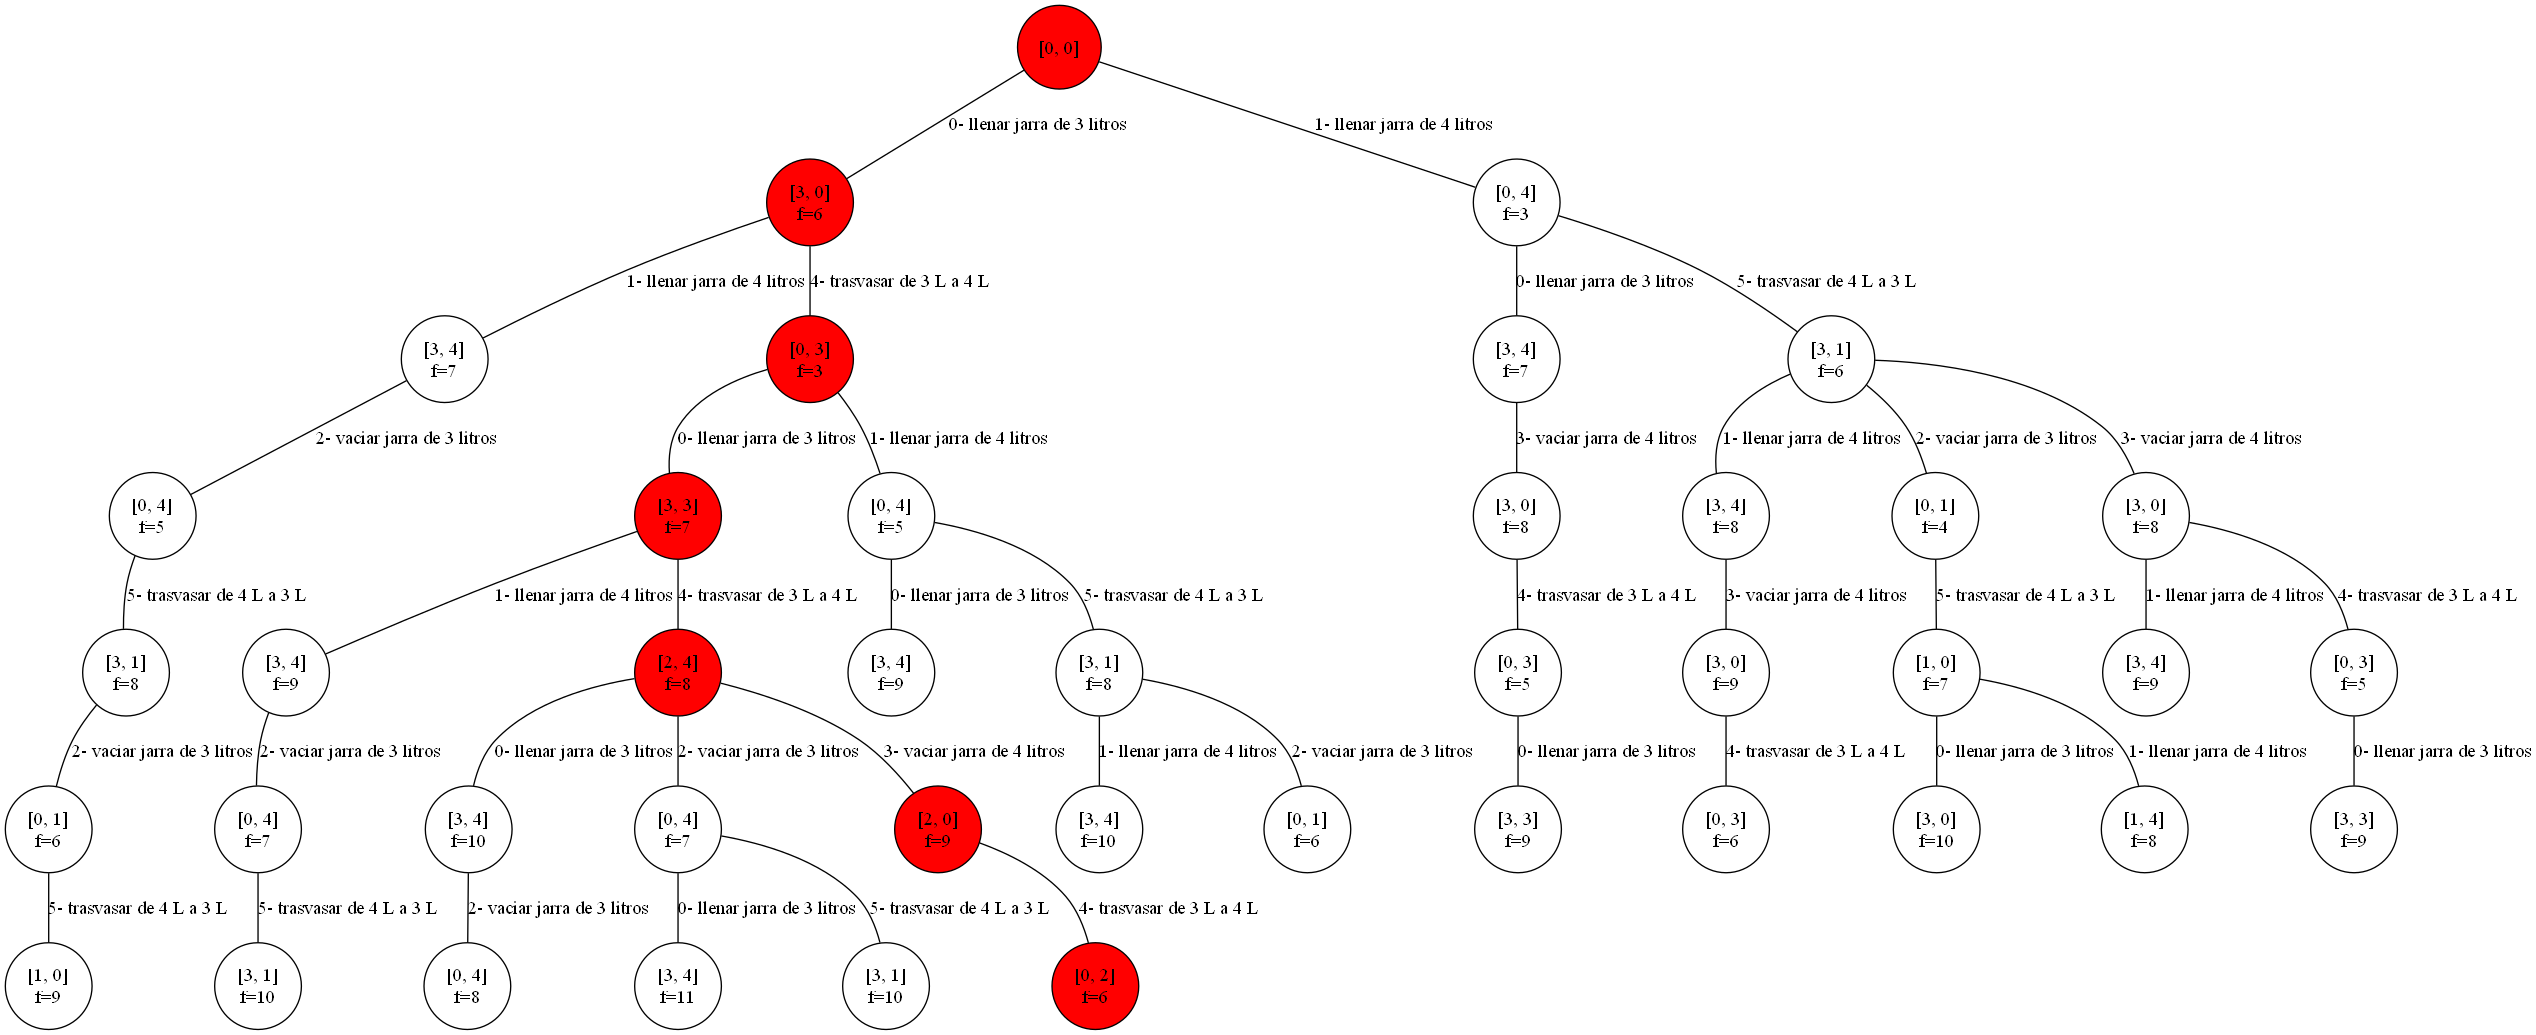

In [13]:
jarObjective = jarProblem.breadthFirst(jar_end_state)
jarBreadthPath = showResult(jarProblem, jarObjective)

### Primero en profundidad

[0, 0]
operador: 0- llenar jarra de 3 litros	 estado: [3, 0]
operador: 1- llenar jarra de 4 litros	 estado: [3, 4]
operador: 2- vaciar jarra de 3 litros	 estado: [0, 4]
operador: 5- trasvasar de 4 L a 3 L	 estado: [3, 1]
operador: 2- vaciar jarra de 3 litros	 estado: [0, 1]
operador: 5- trasvasar de 4 L a 3 L	 estado: [1, 0]
operador: 1- llenar jarra de 4 litros	 estado: [1, 4]
operador: 5- trasvasar de 4 L a 3 L	 estado: [3, 2]
operador: 2- vaciar jarra de 3 litros	 estado: [0, 2]
Costo total: 9


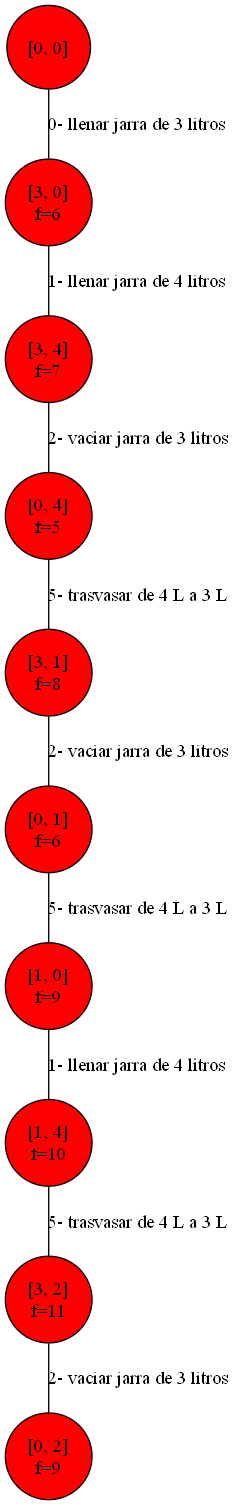

In [14]:
jarObjective = jarProblem.depthFirst(jar_end_state)
jarDepthPath = showResult(jarProblem, jarObjective, width=100, height=700)

### Primero el mejor

[0, 0]
operador: 1- llenar jarra de 4 litros	 estado: [0, 4]
operador: 5- trasvasar de 4 L a 3 L	 estado: [3, 1]
operador: 2- vaciar jarra de 3 litros	 estado: [0, 1]
operador: 5- trasvasar de 4 L a 3 L	 estado: [1, 0]
operador: 1- llenar jarra de 4 litros	 estado: [1, 4]
operador: 5- trasvasar de 4 L a 3 L	 estado: [3, 2]
operador: 2- vaciar jarra de 3 litros	 estado: [0, 2]
Costo total: 7


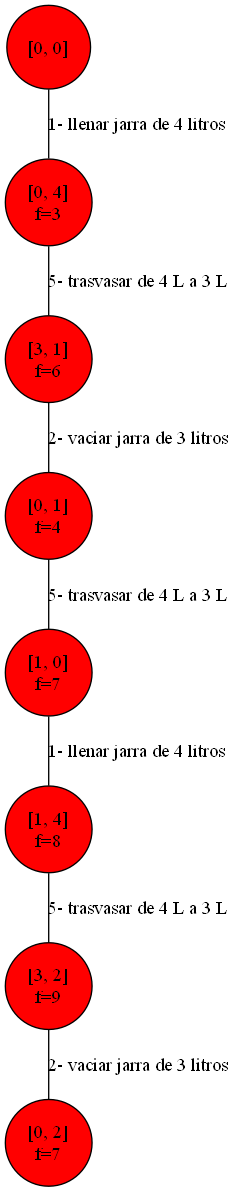

In [15]:
jarObjective = jarProblem.bestFirst(jar_end_state)
jarBestPath = showResult(jarProblem, jarObjective, width=100, height=600)

### A\*

[0, 0]
operador: 0- llenar jarra de 3 litros	 estado: [3, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 3]
operador: 0- llenar jarra de 3 litros	 estado: [3, 3]
operador: 4- trasvasar de 3 L a 4 L	 estado: [2, 4]
operador: 3- vaciar jarra de 4 litros	 estado: [2, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 2]
Costo total: 6


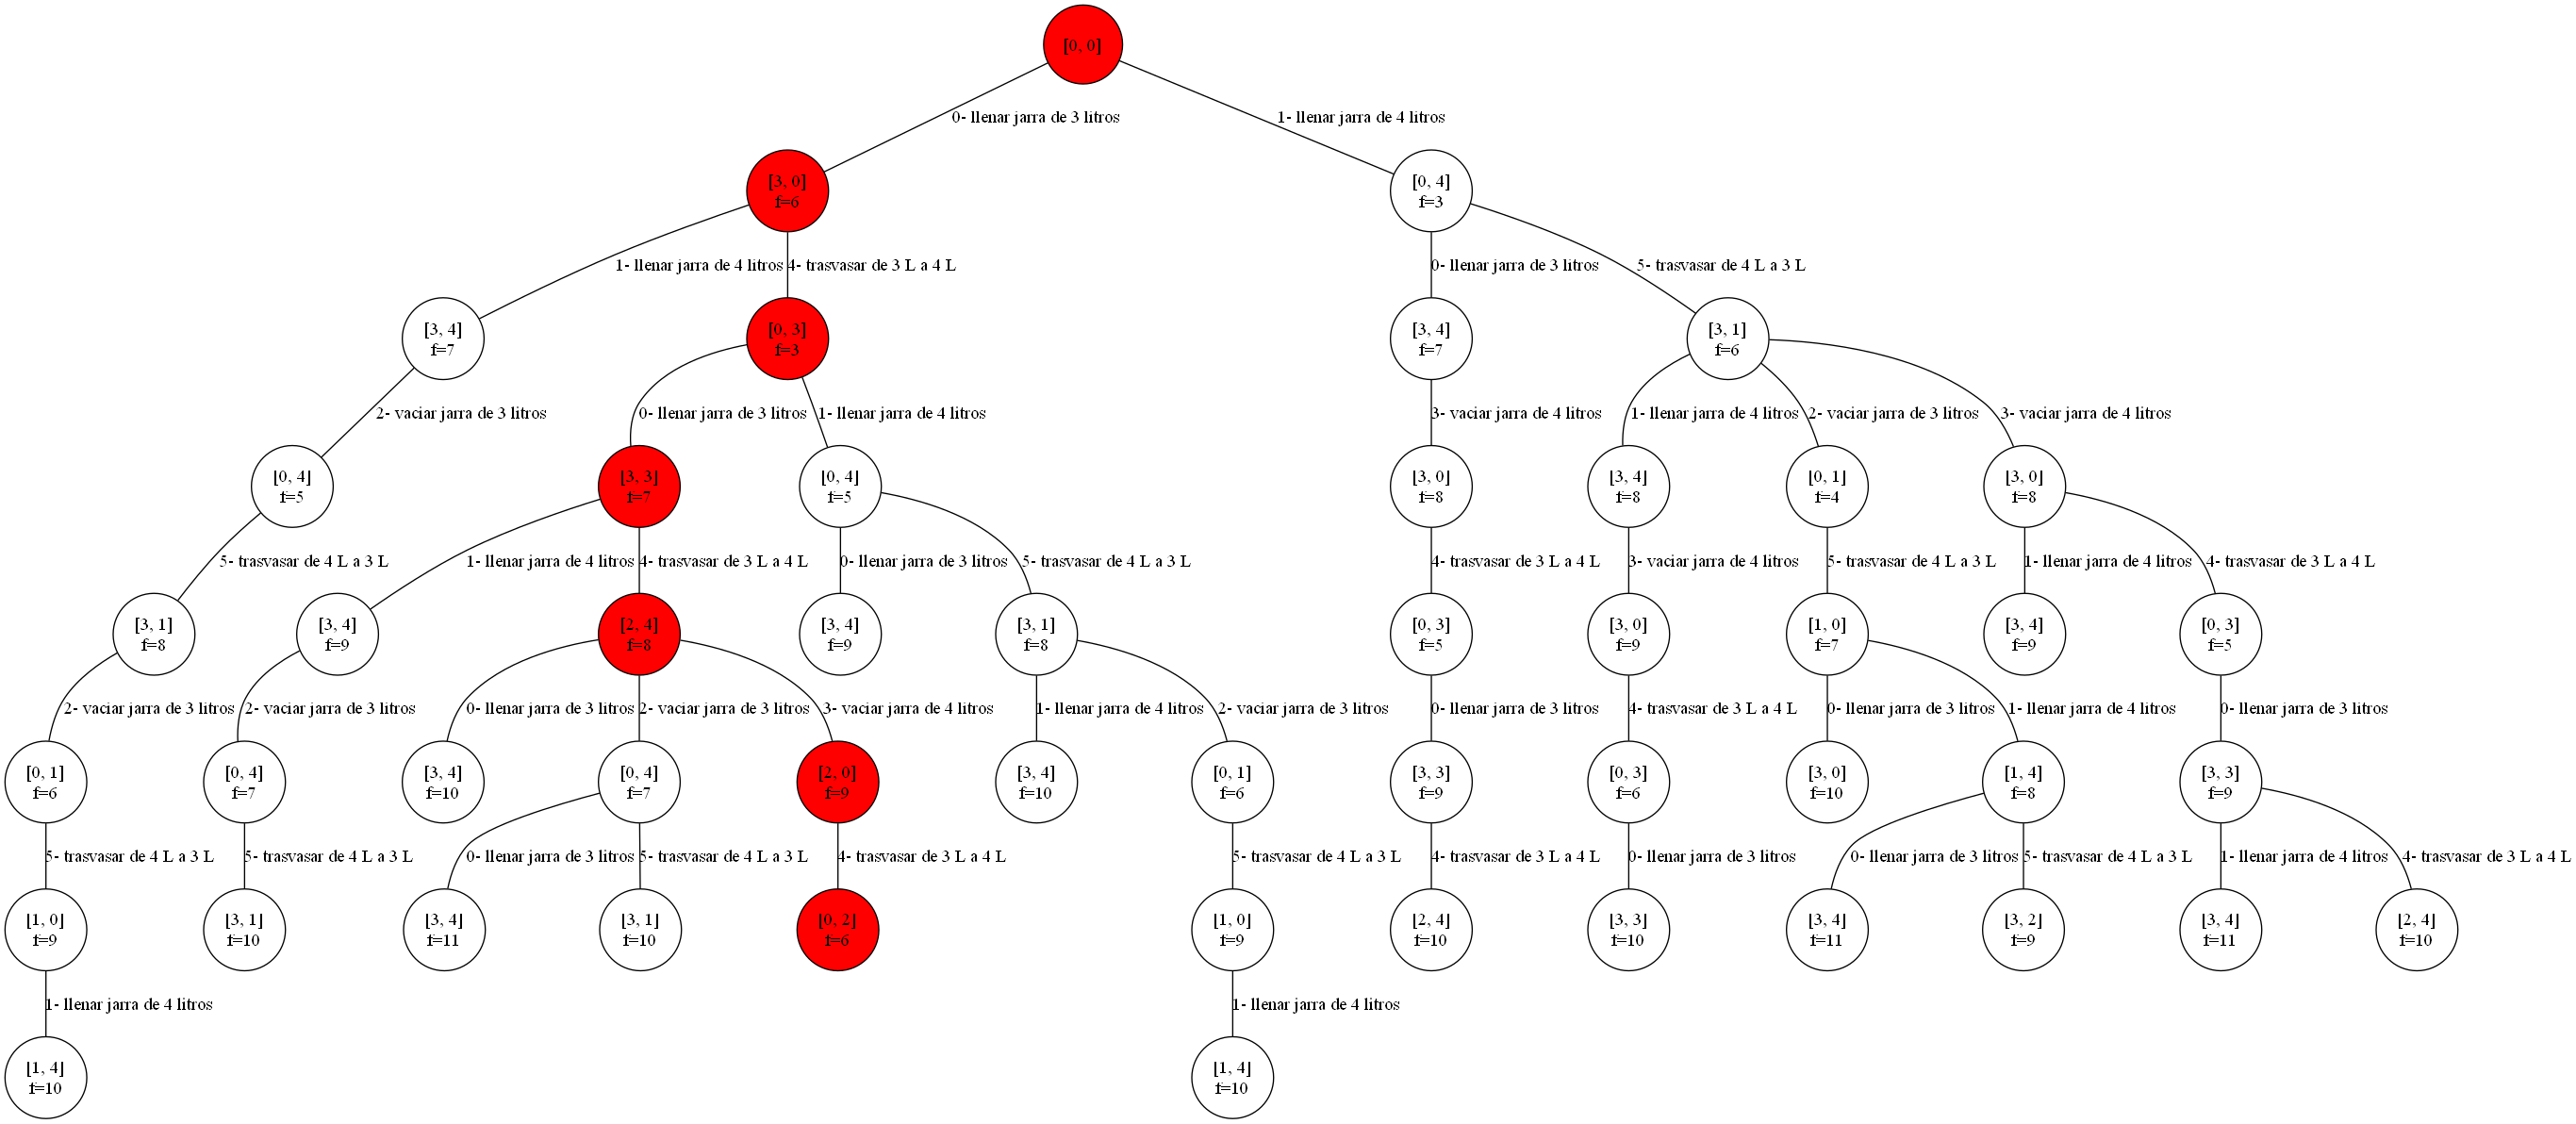

In [16]:
jarObjective = jarProblem.aStar(jar_end_state)
jarAStarPath = showResult(jarProblem, jarObjective)

### Costo uniforme

[0, 0]
operador: 0- llenar jarra de 3 litros	 estado: [3, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 3]
operador: 0- llenar jarra de 3 litros	 estado: [3, 3]
operador: 4- trasvasar de 3 L a 4 L	 estado: [2, 4]
operador: 3- vaciar jarra de 4 litros	 estado: [2, 0]
operador: 4- trasvasar de 3 L a 4 L	 estado: [0, 2]
Costo total: 6


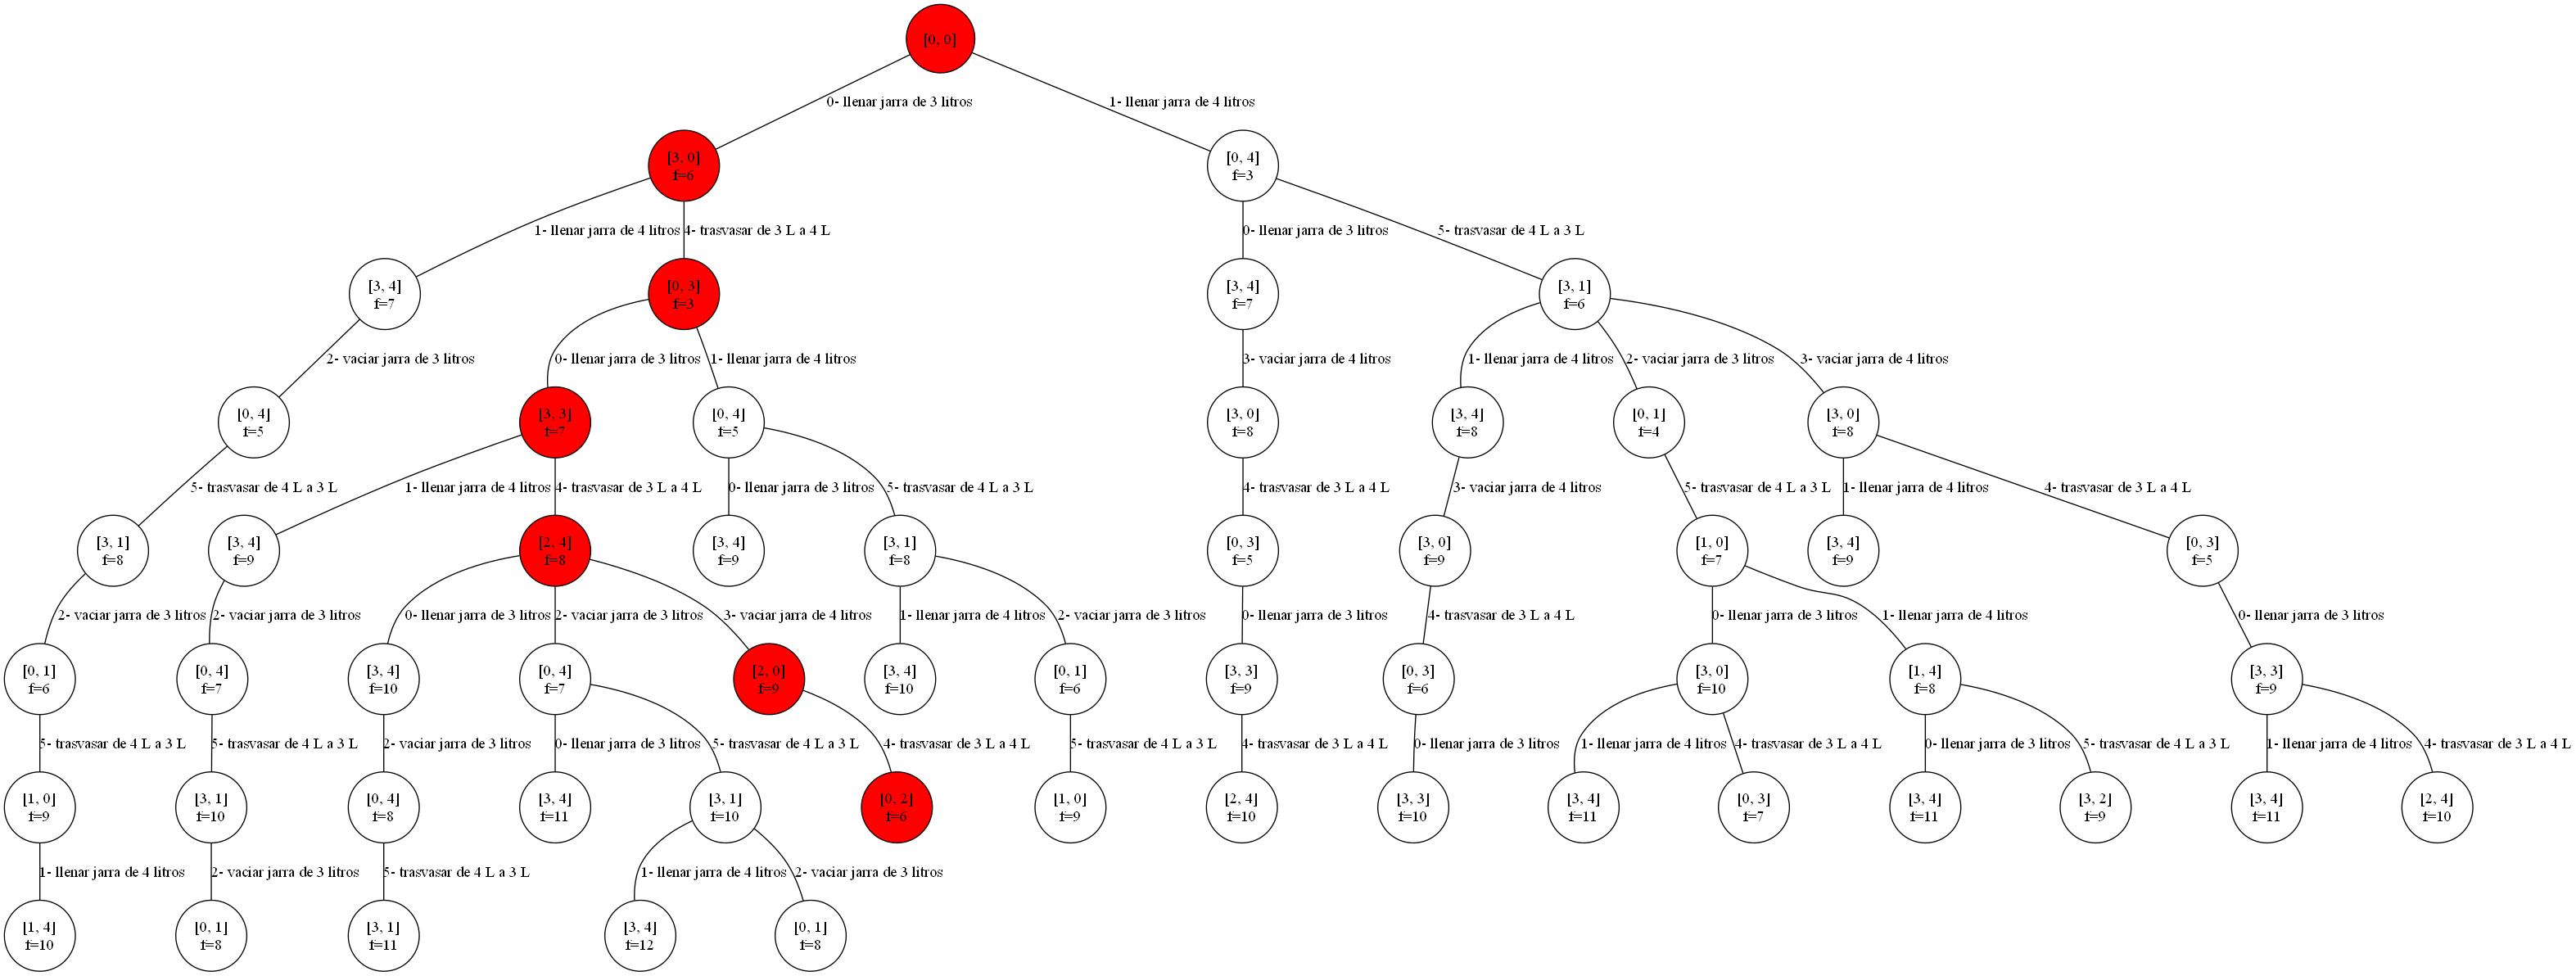

In [17]:
jarObjective = jarProblem.uniformCost(jar_end_state)
jarUniformPath = showResult(jarProblem, jarObjective)

## 5. Mapa de ciudades de Rumania

Se busca un camino desde **Arad** hasta **Bucharest**.

- El estado de un nodo es el nombre de la ciudad.
- Los operadores son las ciudades adyacentes.
- El costo `g(n)` es la distancia acumulada por carretera.
- La heurística `h(n)` es la distancia aérea desde la ciudad actual hasta Bucharest.
- A\* usa `f(n) = g(n) + h(n)`.

El mapa está guardado como una lista de adyacencia: solamente registra carreteras que existen. `findAdjacents()` también busca las conexiones escritas en sentido contrario porque las carreteras son bidireccionales.

In [18]:
romania_map = dict(
    Arad=dict(Zerind=75, Sibiu=140, Timisoara=118),
    Bucharest=dict(Urziceni=85, Pitesti=101, Giurgiu=90, Fagaras=211),
    Craiova=dict(Drobeta=120, Rimnicu=146, Pitesti=138),
    Drobeta=dict(Mehadia=75),
    Eforie=dict(Hirsova=86),
    Fagaras=dict(Sibiu=99),
    Hirsova=dict(Urziceni=98),
    Iasi=dict(Vaslui=92, Neamt=87),
    Lugoj=dict(Timisoara=111, Mehadia=70),
    Oradea=dict(Zerind=71, Sibiu=151),
    Pitesti=dict(Rimnicu=97),
    Rimnicu=dict(Sibiu=80),
    Urziceni=dict(Vaslui=142),
)

aerial_distance_Bucharest = dict(
    Arad=366,
    Bucharest=0,
    Craiova=160,
    Drobeta=242,
    Eforie=161,
    Fagaras=178,
    Giurgiu=77,
    Hirsova=151,
    Iasi=226,
    Lugoj=244,
    Mehadia=241,
    Neamt=234,
    Oradea=380,
    Pitesti=98,
    Rimnicu=193,
    Sibiu=253,
    Timisoara=329,
    Urziceni=80,
    Vaslui=199,
    Zerind=374,
)

route_initial_state = "Arad"
route_end_state = "Bucharest"

In [19]:
class RouteMap(Node):
    # El mapa y las distancias son compartidos por todos los nodos RouteMap.
    mapAdj = None
    distanceA = None

    def __init__(self, mapAdj=None, distanceA=None, **kwargs):
        # **kwargs reúne los argumentos correspondientes a Node.
        if mapAdj is not None:
            RouteMap.mapAdj = mapAdj

        if distanceA is not None:
            RouteMap.distanceA = distanceA

        # Inicializa state, value, parent, operator y demás atributos de Node.
        super(RouteMap, self).__init__(**kwargs)

        # Cada ciudad tiene su propia lista dinámica de adyacencias.
        self.adjacent = self.findAdjacents()

        # Los operadores guardan solamente los nombres de las ciudades.
        # Las distancias permanecen en self.adjacent.
        self.operators = [city for city, distance in self.adjacent]

    def findAdjacents(self):
        """Devuelve parejas (ciudad adyacente, distancia por carretera)."""
        adjacent = []

        # Conexiones escritas desde la ciudad actual hacia otras ciudades.
        if self.state in RouteMap.mapAdj:
            # items() entrega las parejas (ciudad, distancia).
            # extend() agrega cada pareja individualmente a adjacent.
            adjacent.extend(RouteMap.mapAdj[self.state].items())

        # Busca conexiones escritas en sentido contrario porque el mapa es
        # bidireccional y cada carretera se almacenó una sola vez.
        for city, connections in RouteMap.mapAdj.items():
            if self.state in connections:
                adjacent.append((city, connections[self.state]))

        return adjacent

    def getState(self, index):
        # Aplicar un operador significa viajar a la ciudad correspondiente.
        return self.adjacent[index][0]

    def heuristic(self):
        # Distancia aérea desde la ciudad actual hasta Bucharest.
        return RouteMap.distanceA[self.state]

    def cost(self):
        # La raíz tiene costo acumulado cero.
        if self.parent is None:
            return 0

        # operator conserva el índice original dentro de adjacent del padre.
        stepCost = self.parent.adjacent[self.operator][1]

        # g(n) = costo hasta el padre + costo de la carretera utilizada.
        return self.parent.cost() + stepCost

### Adyacentes y prioridades desde Arad

Esta celda muestra por qué A\* elige primero a Sibiu. No basta con mirar la carretera más corta: se suma la distancia recorrida y la estimación restante.

In [20]:
routeStart = RouteMap(
    mapAdj=romania_map,
    distanceA=aerial_distance_Bucharest,
    value="inicio",
    state=route_initial_state,
    operators=[],
)

print("Hijos dinámicos:", routeStart.getchildrens())
print()

for city, roadDistance in routeStart.adjacent:
    aerialDistance = aerial_distance_Bucharest[city]
    print(
        f"{city}: carretera={roadDistance}, "
        f"heurística={aerialDistance}, "
        f"f={roadDistance + aerialDistance}"
    )

Hijos dinámicos: [(0, 'Zerind'), (1, 'Sibiu'), (2, 'Timisoara')]

Zerind: carretera=75, heurística=374, f=449
Sibiu: carretera=140, heurística=253, f=393
Timisoara: carretera=118, heurística=329, f=447


### A\* de Arad a Bucharest

A\* debe encontrar la ruta de costo total **418 km**:

```text
Arad → Sibiu → Rimnicu → Pitesti → Bucharest
```

Arad
operador: Sibiu	 estado: Sibiu
operador: Rimnicu	 estado: Rimnicu
operador: Pitesti	 estado: Pitesti
operador: Bucharest	 estado: Bucharest
Costo total: 418


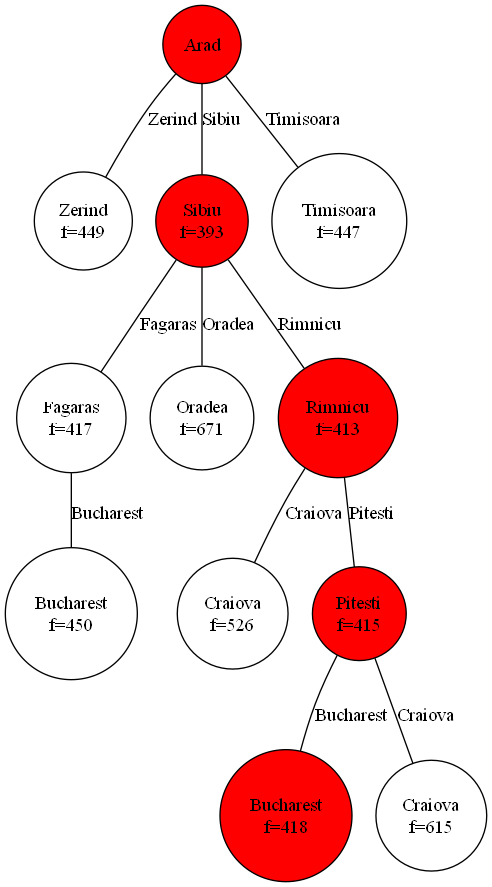

In [21]:
routeProblem = Tree(routeStart)
routeObjective = routeProblem.aStar(route_end_state)
routeAStarPath = showResult(routeProblem, routeObjective, width=700, height=500)

### Primero el mejor

Best-first solamente considera la distancia aérea. Puede llegar rápidamente al destino, pero no garantiza la ruta de menor costo real.

Arad
operador: Sibiu	 estado: Sibiu
operador: Fagaras	 estado: Fagaras
operador: Bucharest	 estado: Bucharest
Costo total: 450


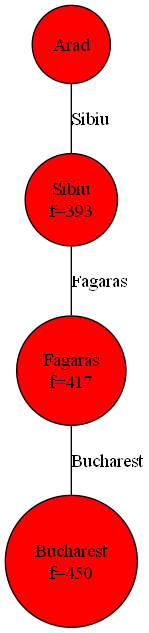

In [22]:
routeObjective = routeProblem.bestFirst(route_end_state)
routeBestPath = showResult(routeProblem, routeObjective, width=600, height=450)

### Costo uniforme

Costo uniforme ignora la distancia aérea y elige siempre el camino con menor costo acumulado. Con costos positivos también encuentra la ruta más barata.

Arad
operador: Sibiu	 estado: Sibiu
operador: Rimnicu	 estado: Rimnicu
operador: Pitesti	 estado: Pitesti
operador: Bucharest	 estado: Bucharest
Costo total: 418


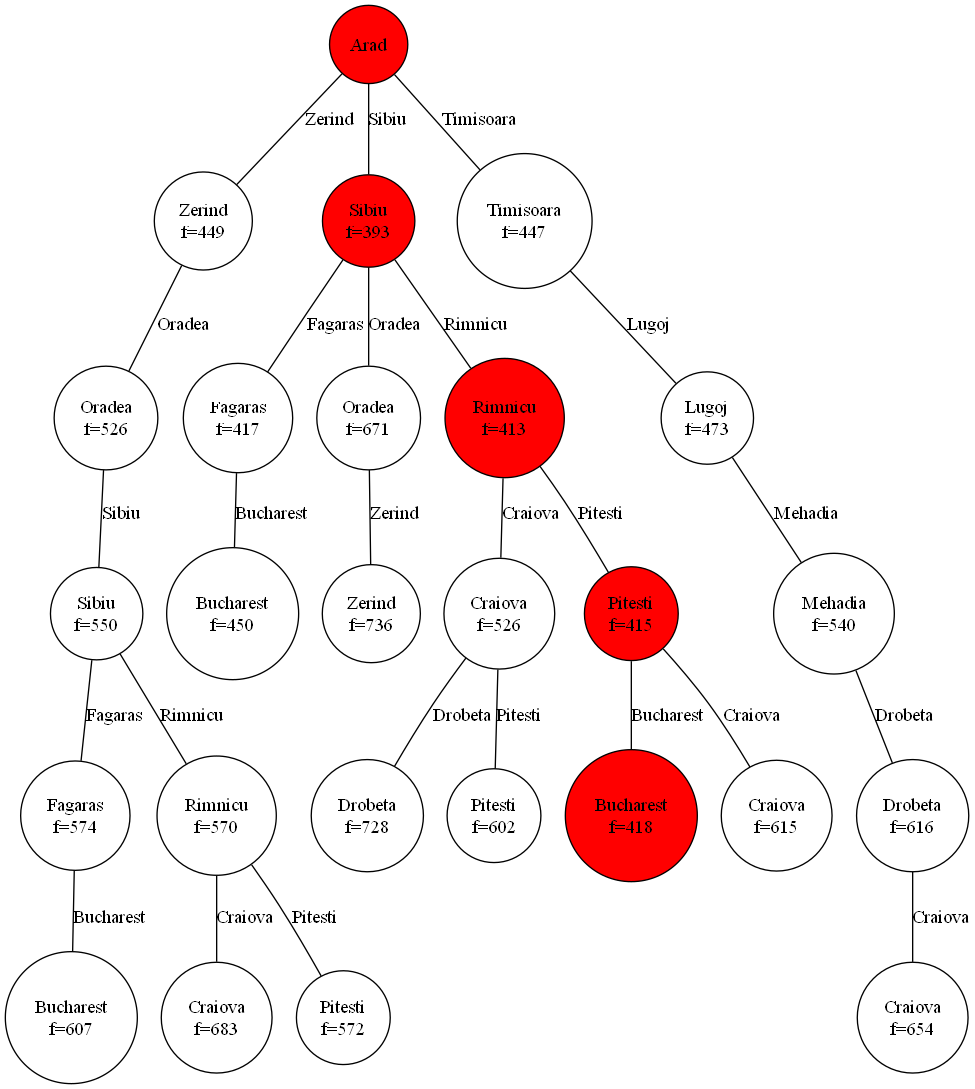

In [23]:
routeObjective = routeProblem.uniformCost(route_end_state)
routeUniformPath = showResult(routeProblem, routeObjective, width=700, height=500)

## 6. Tic-Tac-Toe con Minimax

Se reutilizan `Node` y `Tree` para construir el árbol del juego. Se supone que comienza **MAX**, representado por `X`:

- `player=True`: juega MAX y coloca `X`.
- `player=False`: juega MIN y coloca `O`.
- victoria de `X`: valor `1`.
- victoria de `O`: valor `-1`.
- empate: valor `0`.

Minimax expande las jugadas posibles alternando MAX y MIN. MAX conserva el valor más alto de sus hijos y MIN conserva el más bajo.

In [24]:
class NodeTicTacToe(Node):
    # Se añade el jugador porque la ficha depende del turno actual.
    # True es MAX y False es MIN.
    def __init__(self, player=True, **kwargs):
        super(NodeTicTacToe, self).__init__(**kwargs)
        self.player = player
        # v es el valor inicial genérico, guarda el mejor valor encontrado hasta el momento por cada uno.
        if player:
            self.v = float("-inf")
        else:
            self.v = float("inf")

    # Intenta aplicar una jugada sobre el tablero actual y devuelve el nuevo tablero resultante.
    def getState(self, index):

        # Obtiene el tablero actual y la posicion que se quiere jugar.
        state = self.state
        nextState = None
        x, y = self.operators[index]

        # Solo se puede poner una ficha en una casilla vacía.
        if state[x][y] == " ":
            # Se crea un tablero nuevo, copiandolo.
            nextState = [row.copy() for row in state]

            if self.player is True:
                # MAX coloca X.
                nextState[x][y] = "X"
            else:
                # MIN coloca O.
                nextState[x][y] = "O"

        # Si se realizo una jugada valida, se retorna el tablero
        return nextState if state != nextState else None

    # Costo acumulativo: valor 1 en cada nivel.
    def cost(self):
        return self.level

    # Comprueba si ganó X, ganó O o se produjo un empate.
    def isObjective(self):
        # Copia el tablero
        rows = [row.copy() for row in self.state]
        # Se transpone para sacar sus columnas
        columns = np.array(rows).T

        # Obtiene la diagonal principal y secundaria
        rows.append(np.diag(self.state))
        rows.append(np.flipud(self.state).diagonal())
        rows = np.array(rows)

        # Se unen todas las lineas posibles
        lines = np.concatenate((rows, columns), axis=0)

        for line in lines:
            if line[0] != " " and all(value == line[0] for value in line):
                return True

        # Si no quedan espacios vacíos, hay empate.
        if not np.isin([" "], self.state)[0]:
            return True

        return False

    # Si gana X retorna 1; si gana O retorna -1; si hay empate retorna 0.
    def heuristic(self):
        rows = [row.copy() for row in self.state]
        columns = np.array(rows).T

        rows.append(np.diag(self.state))
        rows.append(np.flipud(self.state).diagonal())
        rows = np.array(rows)

        lines = np.concatenate((rows, columns), axis=0)

        # Estados ganadores para MAX y MIN.
        for line in lines:
            if line[0] != " " and all(value == line[0] for value in line):
                return 1 if line[0] == "X" else -1

        # Si no hay espacios vacios retorna 0.
        if not np.isin([" "], self.state)[0]:
            return 0

        # Evalúa las líneas que todavía están abiertas para un jugador.
        score = 0
        weights = {0: 0, 1: 1, 2: 10}

        for line in lines:
            # count_nonzero cuenta los valores verdaderos.
            x_count = np.count_nonzero(line == "X")
            o_count = np.count_nonzero(line == "O")

            # Una línea sin O todavía puede convertirse en victoria para X.
            if o_count == 0:
                score += weights[x_count]

            # Una línea sin X todavía puede convertirse en victoria para O.
            elif x_count == 0:
                score -= weights[o_count]

        # Mantiene los estados no terminales estrictamente entre -1 y 1.
        return score / (abs(score) + 1)

### Estado inicial y operadores

Cada operador es una posición `(fila, columna)`. Aunque se generan las nueve posiciones, `getchildrens()` devuelve dinámicamente solo las casillas vacías y conserva sus índices originales.

In [25]:
tic_tac_toe_initial_state = [
    ["O", "X", "O"],
    ["O", "X", "X"],
    [" ", " ", "O"],
]

# "Poner una ficha en la casilla vacía (fila, columna)".
tic_tac_toe_operators = [
    (i, j)
    for i, row in enumerate(tic_tac_toe_initial_state)
    for j, cell in enumerate(row)
]

ticTacToeStart = NodeTicTacToe(
    True,
    value="inicio",
    state=tic_tac_toe_initial_state,
    operators=tic_tac_toe_operators,
)
ticTacToeTree = Tree(ticTacToeStart, tic_tac_toe_operators)

print("Operadores:", tic_tac_toe_operators)
print("Hijos válidos:", ticTacToeStart.getchildrens())

Operadores: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
Hijos válidos: [(6, [['O', 'X', 'O'], ['O', 'X', 'X'], ['X', ' ', 'O']]), (7, [['O', 'X', 'O'], ['O', 'X', 'X'], [' ', 'X', 'O']])]


### Ejecución de Minimax

Con `depth=-1`, la profundidad nunca llega a cero y la recursión continúa hasta encontrar victorias o empates. El método devuelve el hijo de la raíz con el mayor valor para MAX.

In [26]:
ticTacToeObjective = ticTacToeTree.miniMax(-1)

print("Mejor operador:", tic_tac_toe_operators[ticTacToeObjective.operator])
print("Valor Minimax:", ticTacToeObjective.v)
print("Estado resultante:")

for row in ticTacToeObjective.state:
    print(row)

Mejor operador: (2, 1)
Valor Minimax: 1
Estado resultante:
['O', 'X', 'O']
['O', 'X', 'X']
[' ', 'X', 'O']


[['O', 'X', 'O'], ['O', 'X', 'X'], [' ', ' ', 'O']]
operador: (2, 1)	 estado: [['O', 'X', 'O'], ['O', 'X', 'X'], [' ', 'X', 'O']]


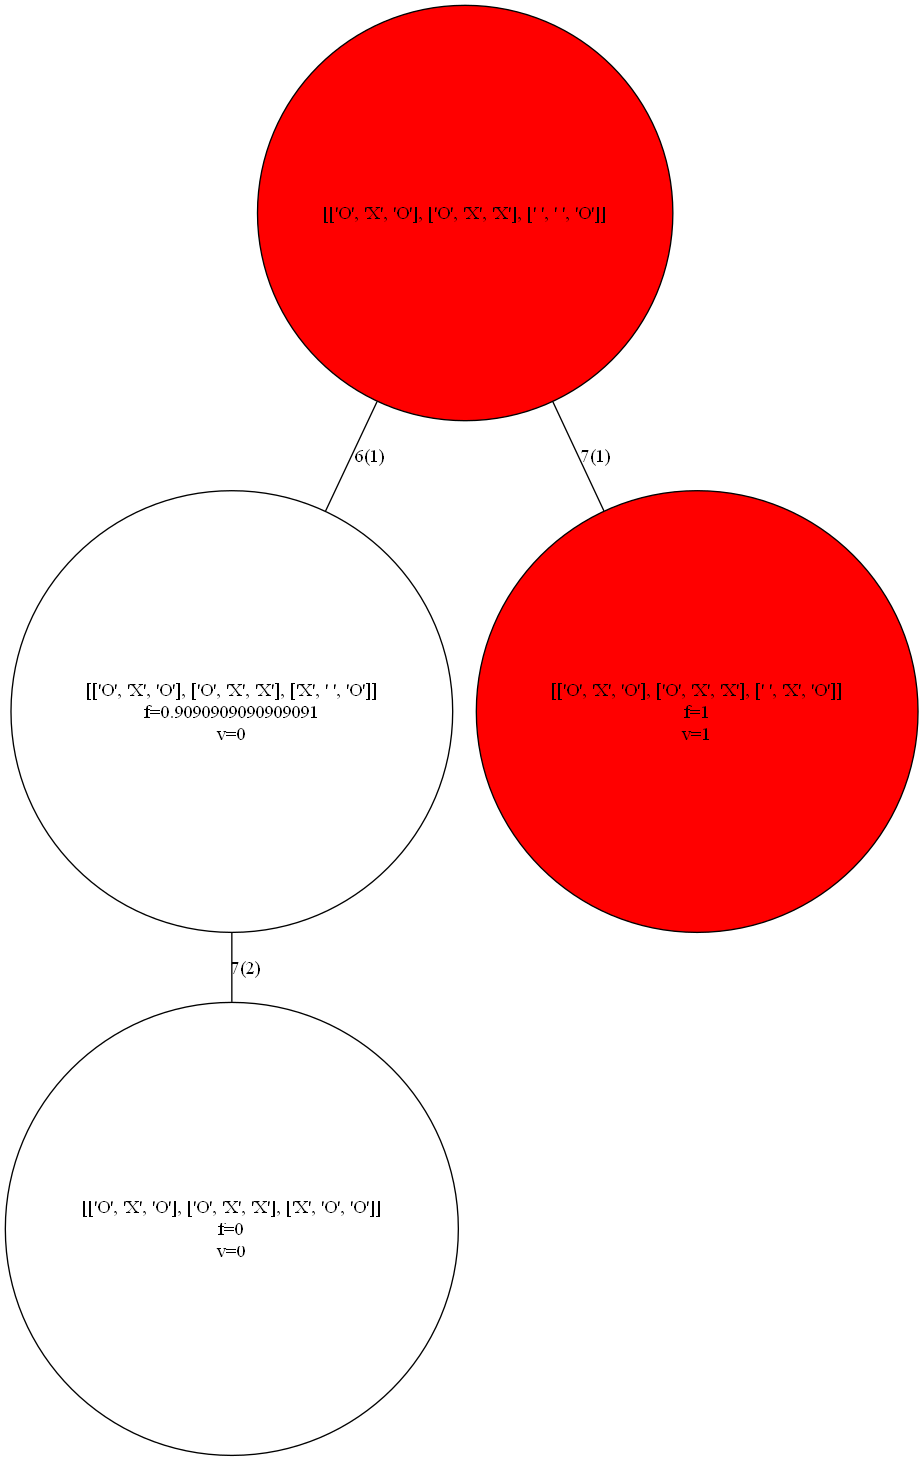

In [27]:
ticTacToePath = ticTacToeTree.printPath(ticTacToeObjective)
ticTacToeGraph = ticTacToeTree.drawMiniMax(ticTacToePath.copy())
ticTacToeImage = Image(ticTacToeGraph.create_png(), width=600, height=600)
display(ticTacToeImage)

## 7. Comparación de los algoritmos

| Algoritmo | Estructura | Prioridad | ¿Usa heurística? | ¿Busca el menor costo? |
|---|---|---|---|---|
| Primero a lo ancho | Cola FIFO | Profundidad | No | Sí, si cada paso cuesta lo mismo |
| Primero en profundidad | Pila LIFO | Último hijo agregado | No | No |
| Primero el mejor | Cola de prioridad | `h(n)` | Sí | No necesariamente |
| A\* | Cola de prioridad | `g(n) + h(n)` | Sí | Sí, con una heurística adecuada |
| Costo uniforme | Cola de prioridad | `g(n)` | No | Sí, con costos no negativos |

### Idea central del flujo

1. Se extrae de la estructura el siguiente nodo que corresponde explorar.
2. `getchildrens()` genera únicamente los hijos válidos como parejas `(índice, estado)`.
3. Cada hijo se convierte en un nuevo nodo que conserva `parent` y `operator`.
4. El nodo se introduce en la cola, pila o cola de prioridad.
5. Al encontrar el objetivo, los enlaces `parent` permiten reconstruir el camino.

En las búsquedas con prioridad, `order` funciona solamente como desempate cuando dos nodos tienen el mismo valor principal.